Module importing

In [1]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
from multiResUnet_1D import MultiResUnet
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

Data prepairing

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_4636\2586689684.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = ["AF","PAC","PVC"])


265
torch.Size([1, 800])


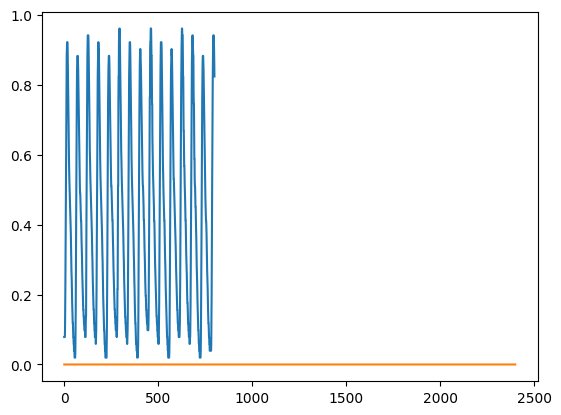

[132, 266, 533]
[[1, 132], [132, 266]]
[266, 533]
[[330, 266], [164, 132]]
[[132, 132], [266, 266]]
[[533, 64], [266, 32]]


C:\Users\Admin\AppData\Local\Temp\ipykernel_4636\2586689684.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = ["AF","PAC","PVC"])


RuntimeError: Index tensor must have the same number of dimensions as input tensor

In [3]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = ["AF","PAC","PVC"])
print(dataset.count)

print(dataset[100][0].shape)
for i in [200]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

import torch.nn.functional as F

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Number class":             3,
			"Serie length":         800, #The length of the 1D data
            "Filter nums":          [32,64,128], #The number of filters for each multiresblocks of one side of the model (1xn) 
            "Expand":               [2,2,2], #The number of stride (1x[n-1])
			"Respath kernel":       3, #The kernel size of each respath (1x1)
            "Block kernel":         [3,5,7], #The kernel size of each multiresblocks (1x3)
			"Filter rate":          [1.67,0.333,0.5], #The ratio of filer number of each multiresblock (1x3)
			"Pooling kernel":       [2,2,2], #The kernel size of each pooling layer (1xn)
			"Transpose kernel":     [2,2,2]	#
    }

def loss(predict, truth):
    truth = truth.to(torch.int64)  # Ensure labels are int64 for PyTorch compatibility
    log_prob = F.log_softmax(predict, dim=1)  # Compute log-softmax
    loss = -log_prob.gather(dim=1, index=truth.unsqueeze(1)).squeeze(1)  # Gather log probabilities of the correct classes
    return loss.mean()

model = MultiResUnet(para = para, alpha = 1.67)
model.structure_calculate(True)
y = model(dataset[1][0].unsqueeze(1))
print(loss(y,dataset[1][1]).cpu().detach().numpy())
plt.plot(y.cpu().detach().numpy().flatten())

plt.show()

Training

In [4]:
import torch.nn.functional as F

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Number class":             1,
			"Serie length":         800, #The length of the 1D data
            "Filter nums":          [32,64,128], #The number of filters for each multiresblocks of one side of the model (1xn) 
            "Expand":               [2,2,2], #The number of stride (1x[n-1])
			"Respath kernel":       3, #The kernel size of each respath (1x1)
            "Block kernel":         [3,5,7], #The kernel size of each multiresblocks (1x3)
			"Filter rate":          [1.67,0.333,0.5], #The ratio of filer number of each multiresblock (1x3)
			"Pooling kernel":       [2,2,2], #The kernel size of each pooling layer (1xn)
			"Transpose kernel":     [2,2,2]	#
    }

def loss(predict, truth):
    truth = truth.to(torch.int64)  # Ensure labels are int64 for PyTorch compatibility
    log_prob = F.log_softmax(predict, dim=1)  # Compute log-softmax
    loss = -log_prob.gather(dim=1, index=truth.unsqueeze(1)).squeeze(1)  # Gather log probabilities of the correct classes
    return loss.mean()

model = MultiResUnet(para = para, alpha = 1.67)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
builder = k_fold_training(dataset, 4, criterion = nn.MSELoss())
builder.training(model,device,optimizer,num_epochs=500,batch=64,visualize=1)

Fold : 1
Train and validate dataset are overlap:  False


d:\313\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([64, 1, 3, 800])) that is different to the input size (torch.Size([64, 1, 800])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
d:\313\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([6, 1, 3, 800])) that is different to the input size (torch.Size([6, 1, 800])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
d:\313\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 1, 3, 800])) that is different to the input size (torch.Size([1, 1, 800])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, 

Iteration: 1/500. loss_train: 0.92522132396698. loss_val: 0.9174315929412842
Iteration: 2/500. loss_train: 0.9349604249000549. loss_val: 0.917431652545929
Iteration: 3/500. loss_train: 0.9359831213951111. loss_val: 0.9174317121505737
Iteration: 4/500. loss_train: 0.9241514801979065. loss_val: 0.917431652545929
Iteration: 5/500. loss_train: 0.9300358295440674. loss_val: 0.917431652545929
Iteration: 6/500. loss_train: 0.9231130480766296. loss_val: 0.9174317121505737
Iteration: 7/500. loss_train: 0.9503792524337769. loss_val: 0.9174315333366394
Iteration: 8/500. loss_train: 0.935998797416687. loss_val: 0.9174315929412842
Iteration: 9/500. loss_train: 0.9126346111297607. loss_val: 0.917431652545929
Iteration: 10/500. loss_train: 0.9377924203872681. loss_val: 0.917431652545929
Iteration: 11/500. loss_train: 0.9377924799919128. loss_val: 0.9174317121505737
Iteration: 12/500. loss_train: 0.9241357445716858. loss_val: 0.9174317121505737
Iteration: 13/500. loss_train: 0.9377924799919128. loss_v

d:\313\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([7, 1, 3, 800])) that is different to the input size (torch.Size([7, 1, 800])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Iteration: 1/500. loss_train: 0.9319917559623718. loss_val: 0.933061957359314
Iteration: 2/500. loss_train: 0.9419715404510498. loss_val: 0.9330620169639587
Iteration: 3/500. loss_train: 0.9142190217971802. loss_val: 0.933061957359314
Iteration: 4/500. loss_train: 0.920885443687439. loss_val: 0.933061957359314
Iteration: 5/500. loss_train: 0.934576153755188. loss_val: 0.933061957359314
Iteration: 6/500. loss_train: 0.9248217344284058. loss_val: 0.9330620169639587
Iteration: 7/500. loss_train: 0.9354243278503418. loss_val: 0.9330618977546692
Iteration: 8/500. loss_train: 0.9345893859863281. loss_val: 0.933061957359314
Iteration: 9/500. loss_train: 0.9408184289932251. loss_val: 0.933061957359314
Iteration: 10/500. loss_train: 0.9404076337814331. loss_val: 0.9330618977546692
Iteration: 11/500. loss_train: 0.9248349666595459. loss_val: 0.933061957359314
Iteration: 12/500. loss_train: 0.932256817817688. loss_val: 0.933061957359314
Iteration: 13/500. loss_train: 0.9428859949111938. loss_val:

KeyboardInterrupt: 

Performance

In [7]:
shower = performance()
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.MSELoss()
for i in range(100):
    output = torch.stack([test_data[i][1]]).to(device)
    print(output.shape)
    input = torch.stack([test_data[i][0]]).to(device)
    print(input.shape)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    sig = input.cpu().detach().numpy().flatten()[0:1000]
    y = output.cpu().detach().numpy()
    ly = np.argmax(y,axis=-2)
    y_hat = y_hat.cpu().detach().numpy()
    ly_hat = np.argmax(y_hat,axis=-2)
    plt.plot(sig)
    plt.plot(ly.flatten()[0:1000])
    plt.plot(ly_hat.flatten()[0:1000])


    # Show plot
    plt.show()

NameError: name 'test_data' is not defined